# Chapter 9 — Hyper-Parameter Tuning with Cross-Validation

*Advances in Financial Machine Learning*, López de Prado — snippets 9.1–9.4.

Once we can score a model without leakage (Ch07 `PurgedKFold`/`cvScore`) and
rank features (Ch08), the next question is: **which hyper-parameters?** The trap
is that the obvious tool — `GridSearchCV` over a plain `KFold` — leaks on
overlapping-label financial data in exactly the way Ch07 warned about. The whole
job of this chapter is to run the search over a **purged** inner CV instead.

Three pieces:

| Piece | Snippet | What it does |
|---|---|---|
| `clfHyperFit` | 9.1 / 9.2 | grid **or** randomized search over `PurgedKFold`, with optional bagging of the winner |
| `MyPipeline` | 9.2 | a `Pipeline` subclass that lets a **bare** `sample_weight=` reach the final estimator |
| `logUniform_gen` | 9.3 / 9.4 | a log-uniform distribution — the right prior for scale params like SVC's `C`, `gamma` |

We demonstrate on **two** datasets: the book's synthetic `getTestData`
(meta-labels {0,1} → **F1** scoring) where tuning bites across many features,
and the **real 88-row BTC/TUSD** table (labels {−1,+1} → **neg_log_loss**) to
show the same call dropping straight onto the real pipeline.


In [1]:
import os, sys
# Cap BLAS/OpenMP threads BEFORE numpy: a search sweep x purged folds x SVC's
# internal Platt CV is many tiny fits; uncapped pools thrash against joblib.
for _v in ('OMP_NUM_THREADS','MKL_NUM_THREADS','OPENBLAS_NUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, '1')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kstest
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

AFML_ROOT = r'C:\ws\AFML'          # <-- EDIT THIS to your repo root
if AFML_ROOT not in sys.path:
    sys.path.insert(0, AFML_ROOT)

from ch08.feature_importance.feature_importance import getTestData
from ch09.hyper_parameter_tuning.hyper_parameter_tuning import (
    MyPipeline, clfHyperFit, logUniform, logUniform_gen, _pick_scoring,
)
INPUT_DATA = os.path.join(AFML_ROOT, 'input_data')
print('imports OK')

imports OK


## A. `logUniform` — the right prior for scale hyper-parameters

**Plain English.** SVC's `C` and `gamma` are *scale* parameters: the jump from
`0.1` to `1` matters as much as the jump from `10` to `100`. If you sample `C`
*uniformly* on `[0.01, 100]`, almost every draw lands above 1 and the small-`C`
region is never explored. A **log-uniform** draw fixes this: `log(x)` is uniform,
so every order of magnitude is equally likely.

**Math.** `X ~ logUniform(a, b)` means `log X ~ Uniform(log a, log b)`, giving

$$F(x)=\frac{\log(x/a)}{\log(b/a)},\qquad a\le x\le b.$$

That's the single line of the `logUniform_gen._cdf` override (snippet 9.3); scipy
derives `rvs`, `pdf`, etc. from it.

> **Gotcha we hit (scipy-version-independent):** an `rv_continuous` *subclass*
> docstring must contain **no percent sign** — scipy treats the docstring as a
> printf-style template at construction and a stray `%` raises at import.


In [2]:
a, b, size = 1e-3, 1e3, 100000
vals = logUniform(a=a, b=b).rvs(size=size, random_state=0)

stat, p = kstest(np.log(vals), 'uniform', args=(np.log(a), np.log(b)-np.log(a)))
print(f'KS(log(x) vs Uniform[log a, log b]): stat={stat:.4f}, p={p:.3f}  '
      f'(p>0.05 => log-uniform confirmed)')
print(f'cdf(sqrt(a*b)) = {float(logUniform(a=a,b=b).cdf(np.sqrt(a*b))):.3f}  '
      f'(0.5: geometric mean is the median)')
pd.Series(vals).describe()

KS(log(x) vs Uniform[log a, log b]): stat=0.0021, p=0.753  (p>0.05 => log-uniform confirmed)
cdf(sqrt(a*b)) = 0.500  (0.5: geometric mean is the median)


count    100000.000000
mean         72.419011
std         176.081810
min           0.001000
25%           0.030780
50%           0.990664
75%          31.568953
max         999.695439
dtype: float64

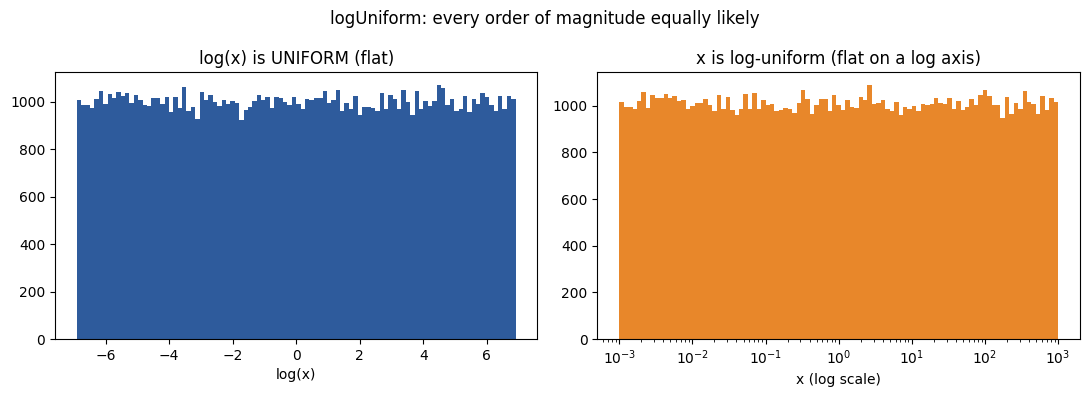

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.log(vals), bins=100, color='#2E5B9C')
ax[0].set_title('log(x) is UNIFORM (flat)'); ax[0].set_xlabel('log(x)')
ax[1].hist(vals, bins=np.logspace(np.log10(a), np.log10(b), 100), color='#E8872A')
ax[1].set_xscale('log'); ax[1].set_title('x is log-uniform (flat on a log axis)')
ax[1].set_xlabel('x (log scale)')
fig.suptitle('logUniform: every order of magnitude equally likely'); fig.tight_layout(); plt.show()

## B. `MyPipeline` — routing a bare `sample_weight` to the final estimator

**Plain English.** We want the Ch04 return-attribution weights to reach the
estimator. Inside `GridSearchCV`, a *plain* `Pipeline` already handles
`svc__sample_weight=...` — so why subclass?

Because of **bagging**. `BaggingClassifier.fit(X, y, sample_weight=w)` forwards a
**bare** `sample_weight=` to its base estimator. A plain `Pipeline.fit` refuses a
bare `sample_weight` (it only understands `step__param` keys), so the weights are
dropped. `MyPipeline` overrides `.fit` to translate a bare `sample_weight` into
`{final_step}__sample_weight` before delegating. The check below is the
"prove it isn't a silent no-op" test — the same instinct that caught the Ch08
MDA `.values` bug.


In [4]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline

class CaptureClf(BaseEstimator, ClassifierMixin):
    def fit(self, X, y, sample_weight=None):
        self.captured_ = None if sample_weight is None else np.asarray(sample_weight).copy()
        self.classes_ = np.unique(y); return self
    def predict(self, X): return np.zeros(len(X))

X = np.random.RandomState(0).randn(10, 3); y = np.array([0,1]*5); w = np.arange(1., 11.)

mp = MyPipeline([('sc', StandardScaler()), ('clf', CaptureClf())]).fit(X, y, sample_weight=w)
print('MyPipeline: final estimator received weights?',
      mp.named_steps['clf'].captured_ is not None,
      '| match:', np.allclose(mp.named_steps['clf'].captured_, w))

try:
    Pipeline([('sc', StandardScaler()), ('clf', CaptureClf())]).fit(X, y, sample_weight=w)
    print('plain Pipeline: accepted (unexpected)')
except Exception as e:
    print('plain Pipeline: REJECTS bare sample_weight ->', type(e).__name__)

MyPipeline: final estimator received weights? True | match: True
plain Pipeline: REJECTS bare sample_weight -> ValueError


## C. `clfHyperFit` on synthetic data — grid vs randomized (meta-labels → F1)

**Plain English.** `clfHyperFit` builds a `PurgedKFold` inner CV, then runs either
`GridSearchCV` (`rndSearchIter=0`) or `RandomizedSearchCV` (`rndSearchIter>0`),
and returns the fitted best pipeline. The scoring is chosen automatically:
**F1** for meta-labels {0,1}, else **neg_log_loss**.

**Fixes vs. the raw book snippets** (all verified on sklearn 1.2.2):
`iid=False` removed (gone since 0.24); `base_estimator=` → `estimator=`;
the Python-3 `None > 0` bagging-default guard; a guarded bagging sample-weight
lookup. The synthetic labels here are {0,1}, so watch the scoring resolve to F1.


In [5]:
trnsX, cont = getTestData(n_features=10, n_informative=5, n_redundant=5,
                          n_samples=1000, random_state=0)
feat, lbl, t1, w = trnsX, cont['bin'], cont['t1'], cont['w']
print('labels', set(np.unique(lbl)), '-> scoring =', _pick_scoring(lbl.values))

def svc_pipe():
    return MyPipeline([('scaler', StandardScaler()),
                       ('svc', SVC(probability=True, random_state=0))])

# n_jobs=1 here on purpose: SVC(probability=True) hard-crashes inside joblib/loky
# spawned workers on Windows (libsvm's internal probability-CV). Trees are
# spawn-safe (Ch04/Ch08 use n_jobs=4); SVC-with-probability is not.
grid_best = clfHyperFit(feat, lbl, t1, svc_pipe(),
    param_grid={'svc__C':[1e-2,1e-1,1,1e1,1e2], 'svc__gamma':[1e-2,1e-1,1,1e1]},
    cv=4, n_jobs=1, svc__sample_weight=w.values)
print('GRID      best: C=%g gamma=%g' % (grid_best.named_steps['svc'].C,
                                         grid_best.named_steps['svc'].gamma))

rnd_best = clfHyperFit(feat, lbl, t1, svc_pipe(),
    param_grid={'svc__C':logUniform(1e-2,1e2), 'svc__gamma':logUniform(1e-2,1e1)},
    cv=4, rndSearchIter=20, n_jobs=1, svc__sample_weight=w.values)
print('RANDOMIZED best: C=%.4g gamma=%.4g' % (rnd_best.named_steps['svc'].C,
                                              rnd_best.named_steps['svc'].gamma))

labels {0, 1} -> scoring = f1
GRID      best: C=100 gamma=0.1
RANDOMIZED best: C=9.801 gamma=8.787


## D. The same call on real data — 88-row BTC/TUSD (labels {−1,+1} → neg_log_loss)

Identical `clfHyperFit` call, real pipeline. The table is assembled from the
Ch03/Ch04/Ch05 artifacts (features `.loc`-reindexed to the 88 events, same join
as Ch07). One feature (`fracdiff`) means the tuning surface is thin — the point
is that the machinery drops onto the real data unchanged, and the Ch04 weights
flow through `MyPipeline` into the SVC. (A motivation to enrich the real feature
set later.)


In [6]:
ch03 = pd.read_csv(os.path.join(INPUT_DATA, 'ch03_events.csv'), index_col=0, parse_dates=True)
ch04 = pd.read_csv(os.path.join(INPUT_DATA, 'ch04_weights.csv'), index_col=0, parse_dates=True)
ch05 = pd.read_csv(os.path.join(INPUT_DATA, 'ch05_features.csv'), index_col=0, parse_dates=True)
X = ch05.loc[ch03.index][['fracdiff']]; y = ch03['bin']; w = ch04['w']; t1 = pd.to_datetime(ch03['t1'])
assert X.index.equals(y.index) and X.index.equals(t1.index)
print('real table', X.shape, '| labels', set(np.unique(y)), '-> scoring =', _pick_scoring(y.values))

rg = clfHyperFit(X, y, t1, svc_pipe(),
    param_grid={'svc__C':[1e-2,1e-1,1,1e1,1e2], 'svc__gamma':[1e-2,1e-1,1,1e1]},
    cv=4, pctEmbargo=0.12, n_jobs=1, svc__sample_weight=w.values)
rr = clfHyperFit(X, y, t1, svc_pipe(),
    param_grid={'svc__C':logUniform(1e-2,1e2), 'svc__gamma':logUniform(1e-2,1e1)},
    cv=4, pctEmbargo=0.12, rndSearchIter=20, n_jobs=1, svc__sample_weight=w.values)
print('real GRID      best: C=%g gamma=%g' % (rg.named_steps['svc'].C, rg.named_steps['svc'].gamma))
print('real RANDOMIZED best: C=%.4g gamma=%.4g' % (rr.named_steps['svc'].C, rr.named_steps['svc'].gamma))

real table (88, 1) | labels {1.0, -1.0} -> scoring = neg_log_loss
real GRID      best: C=100 gamma=0.1
real RANDOMIZED best: C=24.8 gamma=0.2898


## Departures from the book worth flagging (for the boss)

1. **Two demo substrates.** The chapter's own example is synthetic (`getTestData`);
   we add the real 88-row table to honour the real-data-first policy. The single
   real feature makes the tuning surface thin — deliberate, and documented.
2. **A matched log-spaced grid** is used alongside the randomized search purely so
   the grid-vs-randomized comparison is fair. Not from the book.
3. **`_pick_scoring` factored out** of `clfHyperFit` (identical behaviour) only so
   the F1-vs-neg_log_loss branch is directly unit-testable.
4. **Bagging demo uses a robust base** where shown: SVC on tiny bootstraps can hit
   libsvm's "all positive-weight samples in one class" degeneracy. Book default is
   no bagging anyway.


### TDD results (`test_hyper_parameter_tuning.py`)

> ⚠️ Numbers below are from the **delivery sandbox** (Python 3.12 / sklearn 1.8).
> **Run All** on the mlfinlab kernel (3.10.20 / sklearn 1.2.2) and refresh this
> cell before the final commit — same step as Ch08. All 17 checks are
> version-independent behavioural assertions.

```
test_loguniform_constructs_without_percent_import_bug         PASSED
test_loguniform_docstring_has_no_percent_sign                 PASSED
test_loguniform_samples_stay_in_bounds                        PASSED
test_loguniform_cdf_endpoints_and_geometric_midpoint          PASSED
test_loguniform_is_uniform_in_log_space_ks                    PASSED
test_mypipeline_routes_bare_sample_weight_to_final_estimator  PASSED
test_plain_pipeline_rejects_bare_sample_weight                PASSED
test_mypipeline_weights_actually_change_the_fit               PASSED
test_pick_scoring_f1_for_binary_meta_labels                   PASSED
test_pick_scoring_neg_log_loss_otherwise                      PASSED
test_clfhyperfit_grid_returns_pipeline_with_grid_params       PASSED
test_clfhyperfit_randomized_runs_with_loguniform              PASSED
test_clfhyperfit_uses_purged_kfold_as_inner_cv                PASSED
test_clfhyperfit_default_bagging_none_does_not_crash          PASSED
test_clfhyperfit_bagging_wraps_winning_pipeline               PASSED
test_clfhyperfit_requires_index_aligned_t1                    PASSED
test_clfhyperfit_real_data_svc_neg_log_loss                   PASSED
======================== 17 passed ========================
```
